# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Source Modelling**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

In [2]:
MASK_FITS: str = "mask_NTHT_20250725.fits"
UPS_X, UPS_Y = 2, 1

# SKYFIELD: str = "GalacticCentre"
# DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

RUN_ID: str = 'Crab_benchmark_2-6keV'
E_min, E_max = 2.0, 6.0           # [keV]

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
# DATASET: str = "reconstructed"

In [3]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A]["reconstructed"], E_min=E_min, E_max=E_max)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlB = ds.get_data(filepaths[ID_CAMERA_B]["reconstructed"], E_min=E_min, E_max=E_max)
catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, logB = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


In [4]:
from bloodmoon.mask import count, decode, variance
from bloodmoon.optim import model_sky

detector, _ = count(wfm, sdlA.DLdata)
varmap = variance(wfm, detector)
true_skyA = decode(wfm, detector)

### **PSF Slices**

In [5]:
def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "SPSF Fine Axis",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "SPSF Coarse Axis",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

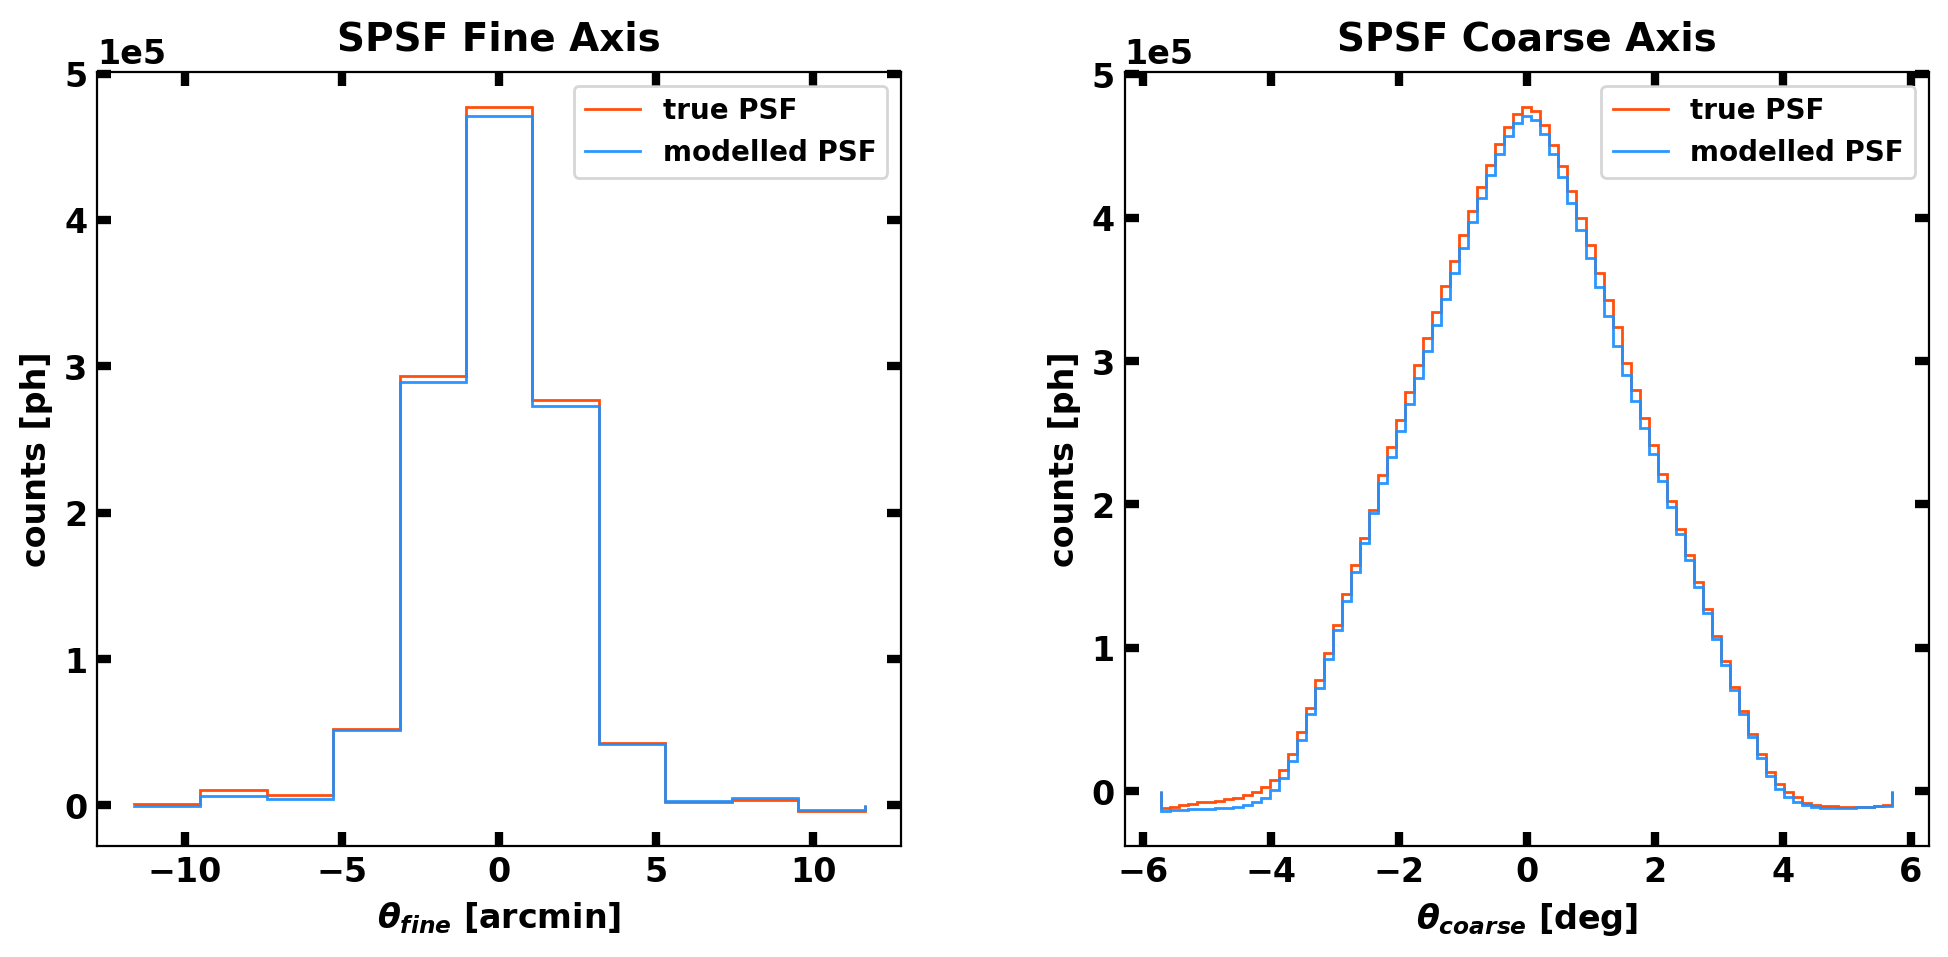

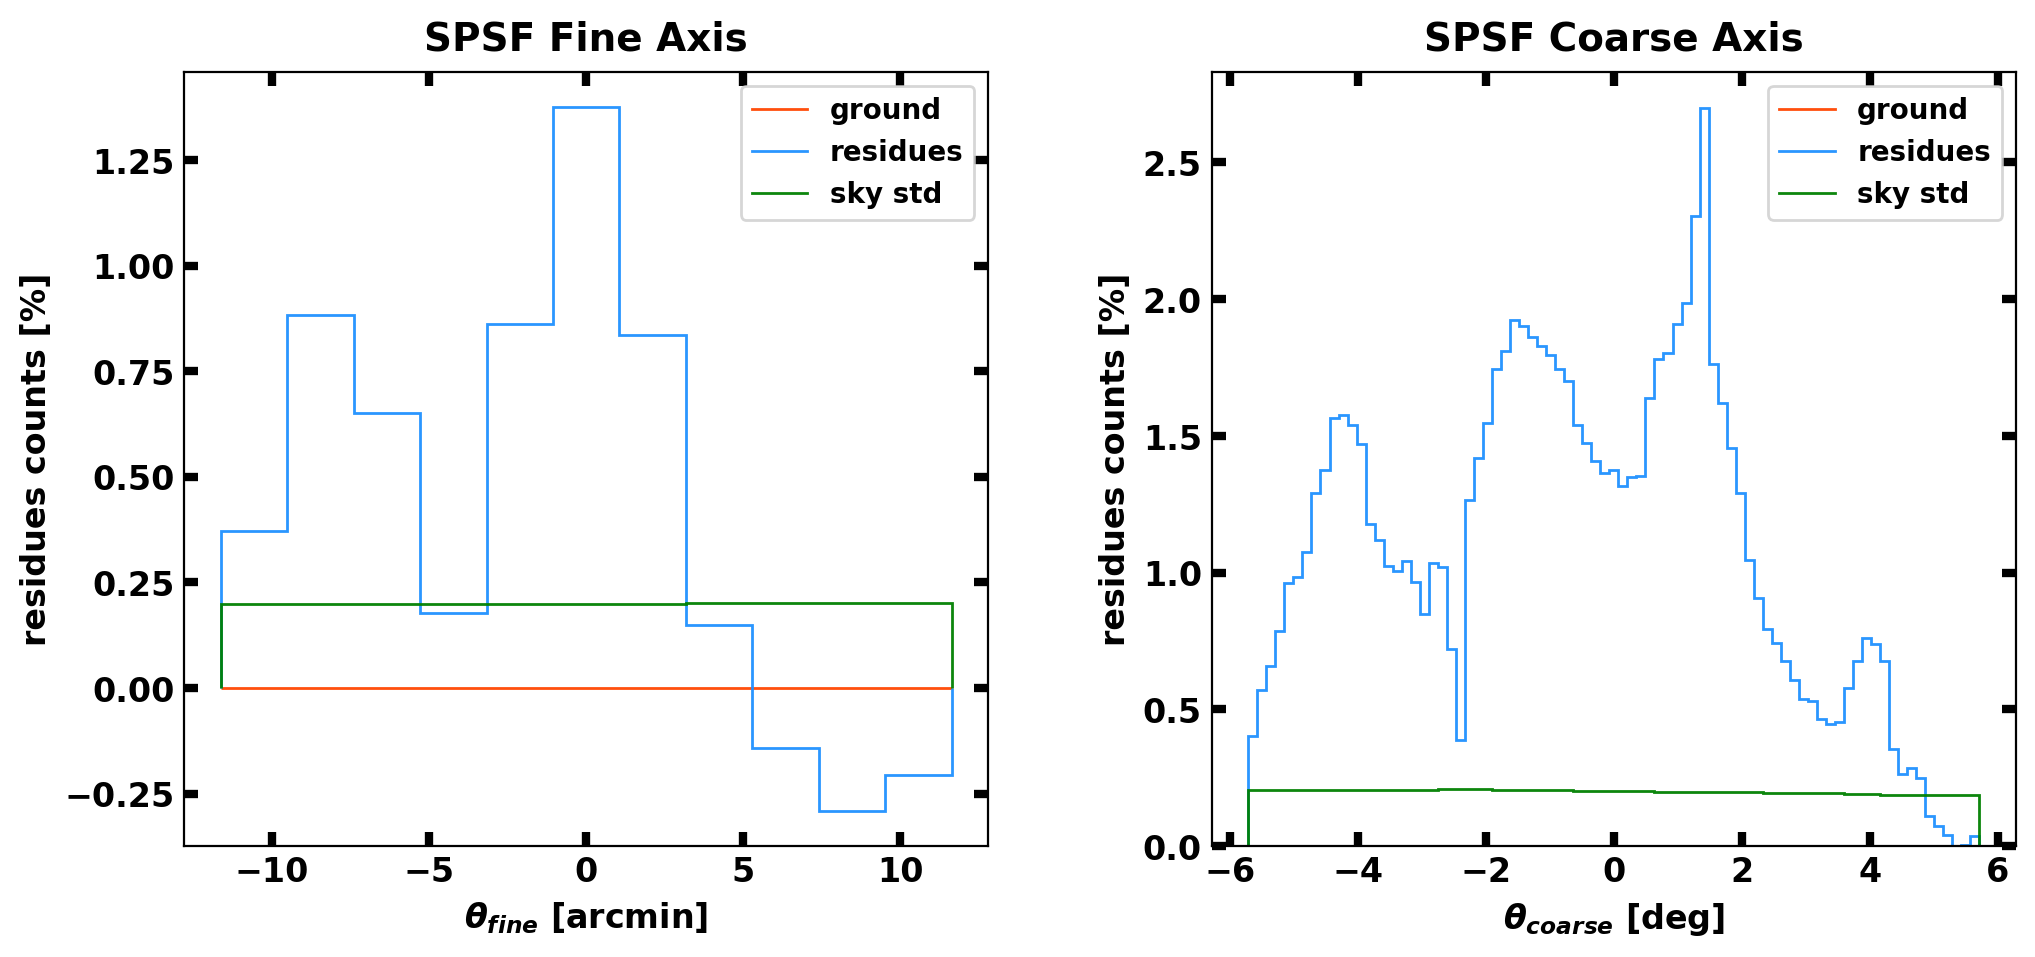

In [10]:
IDX: int = 0   # s17
KWS = {
    'pos': (logA.log['y'][IDX], logA.log['x'][IDX]),
    'crp': (40, 5),
    # 'title_prefix': 'Crab',
    'color': ('OrangeRed', 'DodgerBlue', 'Green'),
    'size': 4.5,
}
PERC: bool = True

template = model_sky(wfm, logA.log['shift_x'][IDX], logA.log['shift_y'][IDX], logA.log['fluence'][IDX])
residues = true_skyA - template
loc_std = np.sqrt(varmap)


custom_slices_plot(
    camera=wfm,
    sky=(true_skyA, template),
    labels=('true PSF', 'modelled PSF'),
    save_to=f'{OUT_RESULTS_PATH}/psf_slices_{E_min}-{E_max}keV.png',
    **KWS,
)
if PERC:
    residues_ = residues * 100 / true_skyA[KWS['pos']]; loc_std_ = loc_std * 100 / true_skyA[KWS['pos']]
else:
    residues_ = residues; loc_std_ = loc_std

custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues_), residues_, loc_std_),
    labels=('ground', 'residues', 'sky std'),
    ylabel=r'residues counts [%]',
    save_to=f'{OUT_RESULTS_PATH}/psf_slices_res_{E_min}-{E_max}keV.png',
    **KWS,
)

### **PSF HeatMaps**

In [12]:
import matplotlib.pyplot as plt
from darksun.show import DSPlot, export_pltparams

def custom_PSF_hmap(
    camera: CodedMaskCamera,
    psf: NDArray,
    residues: NDArray,
    xticks: NDArray,
    yticks: NDArray,
    title_prefix: str | None = None,
    save_to: str | Path | None = None,
    **fig_kws,
) -> None:
    """
    Plots the true PSF of given source and residues wrt `bm` template from IROS.
    """    
    PLOTPARAMS = export_pltparams()
    n, m = psf.shape
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    _yticks_lbl, _xticks_lbl = dty / 60 * (yticks - n // 2), dtx * (xticks - m // 2)
    yticks_lbl, xticks_lbl = map(lambda arr: [float(f'{a:.1f}') for a in arr], (_yticks_lbl, _xticks_lbl))
    aspect = 2 * KWS['crp'][1] / KWS['crp'][0]
    title_prefix_ = f'{title_prefix} ' if title_prefix is not None else ''

    res_ = residues * 100 / psf[(n - 1) // 2, (m - 1) // 2]
    valres = max(abs(res_.min()), abs(res_.max()))

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(ptype='image', **fig_kws)
    fig.subplots_adjust(wspace=-1e-1)

    # - IMG axis 0  |  PSF
    dsp.config_labels(axs[0], f'{title_prefix_}SPSF', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[0].imshow(psf, origin=PLOTPARAMS['cbar_origin'], cmap='gist_heat', aspect=aspect)
    cbar = fig.colorbar(
        img, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'counts [ph]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # - IMG axis 1  |  Residues (true-template)
    dsp.config_labels(axs[1], f'{title_prefix_}SPSF Residues', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[1].imshow(
        res_, origin=PLOTPARAMS['cbar_origin'], cmap='viridis', aspect=aspect, vmin=-valres, vmax=valres,
    )
    cbar = fig.colorbar(
        img, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'residues counts [%]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    
    for ax in axs: dsp.config_ticks(ax, xticks, xticks_lbl, yticks, yticks_lbl)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

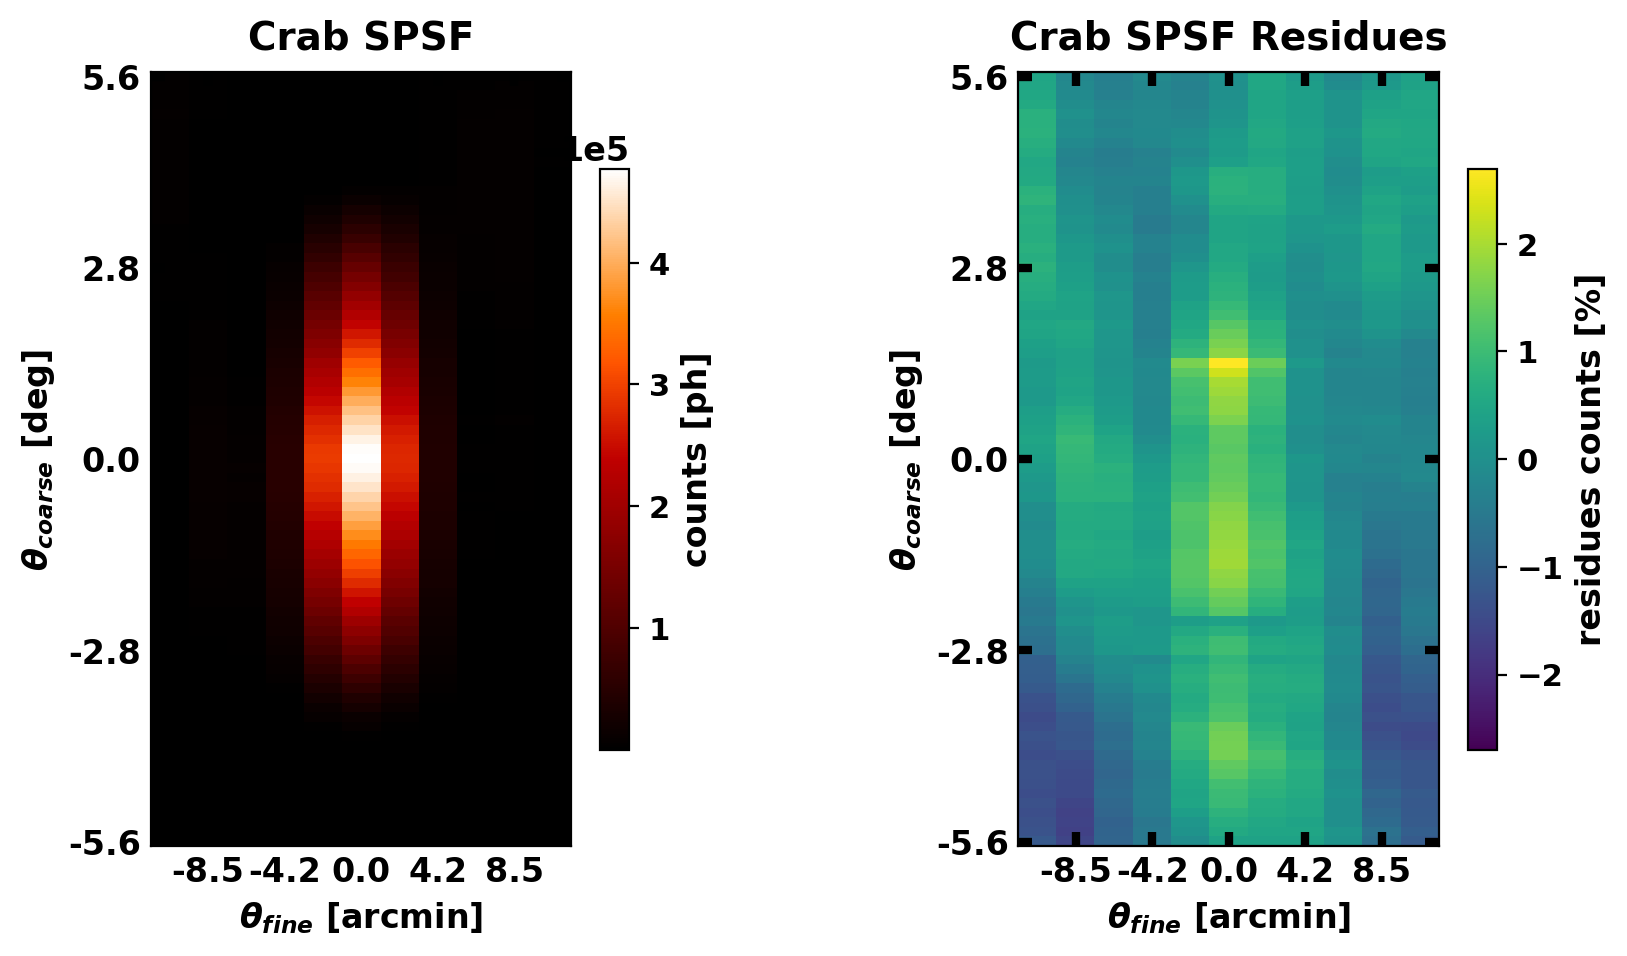

In [13]:
src_psf, src_res = map(lambda x: ds.crop(x, KWS['pos'], KWS['crp']), (true_skyA, residues))

n, m = src_psf.shape
yticks, xticks = np.arange(n)[::20], (np.arange(m)[::2] + 1)[:-1]

custom_PSF_hmap(
    camera=wfm,
    psf=np.clip(src_psf, a_min=1, a_max=src_psf.max()),
    residues=src_res,
    xticks=xticks,
    yticks=yticks,
    title_prefix='Crab',
    save_to=f'{OUT_RESULTS_PATH}/psfHM_{E_min}-{E_max}keV.png',
    size=KWS['size'],
)

<br>

<br>

<br>

## <center>**Instrumental Effects**<center>

In [ ]:
def plot_instr_effects(
    camera: CodedMaskCamera,
    skies: dict[str, NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots instrumental effects on source SPFS.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    def crop_n_slice(sky: NDArray) -> tuple[NDArray, NDArray]:
        """Crops sky array and extracts fine/coarse axis slice."""
        cropped = ds.crop(sky, pos, crp, strict=False)
        return cropped[crp[0], :], cropped[:, crp[1]]
    
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)

    # --- VIGNETTING ---
    dmap_vignetting = ds.map4plot(
        ...,
        title='Vignetting',
    )

    # --- SPATIAL RESOLUTION ---
    dmap_spres = ds.map4plot(
        ...,
        title='Detector Spatial Resolution',
    )

    # --- INCLINED PENETRATION ---
    dmap_incpentr = ds.map4plot(
        ...,
        title='Inclined Penetration',
    )
    
    ds.plot(
        dmaps=(dmap_vignetting, dmap_spres, dmap_incpentr),
        ncols=3,
        save_to=save_to,
        **kwargs,
    )
    return

In [ ]:
wfm_up: CodedMaskCamera = codedmask(MASK_PATH, 10, 4)
sdl_detected = ds.get_data(filepaths[ID_CAMERA_A]["detected"])
sdl_reconstructed = ds.get_data(filepaths[ID_CAMERA_A]["reconstructed"])



skies = {
    'templ_nonVignetted': model_sky(wfm_up),
    'templ_vignetted': ...,
    'true_detected': ...,
    'true_reconstructed': ...,    
}
plot_instr_effects(
    camera=wfm_up,
    skies=skies,
    save_to=f'{OUT_RESULTS_PATH}/instr_effects.pdf',
    size=KWS['size'],
)